<a href="https://colab.research.google.com/github/titille555/Detection-Fraude-Bancaire/blob/main/D%C3%A9tection_de_Fraude_Bancaire_par_Apprentissage_Supervis%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TP TP — Détection de Fraude Bancaire : Analyse Exploratoire et Modélisation par Arbre de Décision (Approche C4.5)

### Synthèse de la Problématique Métier

###Dataset : Fraud Detection.csv

| Élément | Valeur |
| :--- | :--- |
| **Type de problème** | Classification binaire |
| **Variable cible (Y)** | `Fraudulent` (0 = légitime, 1 = frauduleuse) |
| **Variables (X)** | `Transaction_Amount`, `Type`, `Time`, `Device`, `Location`, etc. |
| **Algorithme** | `DecisionTreeClassifier` (criterion='entropy' $\rightarrow$ C4.5) |
| **Question métier** | Peut-on prédire automatiquement si une transaction bancaire est frauduleuse, en produisant des règles interprétables pour les équipes de sécurité ? |

## Phase 0 — Installation et Imports

In [8]:

#Importez toutes les librairies nécessaires pour ce TP.

# Manipulation des données
from google.colab import files
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1 — Data Understanding

In [44]:

##  Chargement des données


# Chargement dans un DataFrame

df = pd.read_csv('Fraud.csv')

# Vérification du chargement
print("Visualisation des données ")
df
#df.head()


Visualisation des données 


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


## Exploration initiale

In [34]:

#Dimension
print(f"\nDimensions du dataset : {df.shape}")

#Type de colonnes
print("\n Types de données :")
print(df.dtypes)

#Résumé statistique
print("\n Résumé statistique :")
df.describe()




Dimensions du dataset : (50119, 12)

 Types de données :
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object

 Résumé statistique :


,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,50119.000000,47643.000000,47614.000000,50119.000000,50119.000000,50119.000000,50119.000000
mean,3004.733195,2999.104599,11.488575,1.996448,60.029071,7.495640,0.049223
std,1152.620471,5061.206189,6.921244,1.415492,34.392569,4.019806,0.216335
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1269.830000,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2997.000000,2523.580000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4005.000000,3785.090000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [37]:
#Vérifier les doublons
print(f"\n Doublons : {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f" Doublons supprimés. Nouveau shape : {df.shape}")



 Doublons : 0


##Analyse des valeurs manquantes

In [43]:
#Valeurs manquantes
print("valeurs manquantes :")
missing = df.isnull().sum()
print(missing[missing > 0 ] if missing.sum() > 0 else "Pas de valeurs manquantes")

# 'unknown' dans les colonnes catégorielles
print("\n Occurrences de 'unknown' par colonne :")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = (unknown_count / len(df)) * 100
        print(f"  {col}: {unknown_count} ({pct:.2f}%)")

    if not unknown_count:
        print(f"  {col}: Aucune valeur 'unknown' détectée.")


valeurs manquantes :
Transaction_Amount     2520
Time_of_Transaction    2552
Device_Used            2473
Location               2547
Payment_Method         2469
dtype: int64

 Occurrences de 'unknown' par colonne :
  Transaction_ID: Aucune valeur 'unknown' détectée.
  Transaction_Type: Aucune valeur 'unknown' détectée.
  Device_Used: Aucune valeur 'unknown' détectée.
  Location: Aucune valeur 'unknown' détectée.
  Payment_Method: Aucune valeur 'unknown' détectée.


In [46]:
# 1. NaN classiques avec pourcentage
print(" Valeurs manquantes (NaN) :")
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0] if missing.sum() > 0 else "Aucun NaN")

# 2. Valeurs "parasites" dans les catégorielles (unknown, invalid, etc.)
print("\n Valeurs suspectes par colonne catégorielle :")
suspicious = ['unknown', 'Unknown', 'Invalid Method', 'N/A', 'none', '-']
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    for val in suspicious:
        count = (df[col] == val).sum()
        if count > 0:
            pct = count / len(df) * 100
            print(f"  {col}: '{val}' → {count} occurrences ({pct:.2f}%)")

 Valeurs manquantes (NaN) :
                     Count   Pct (%)
Transaction_Amount    2520  4.941176
Time_of_Transaction   2552  5.003922
Device_Used           2473  4.849020
Location              2547  4.994118
Payment_Method        2469  4.841176

 Valeurs suspectes par colonne catégorielle :
  Payment_Method: 'Invalid Method' → 1530 occurrences (3.00%)


##Analyse de la variable cible Fraudulent

Fraudulent
0    48490
1     2510
Name: count, dtype: int64
Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64


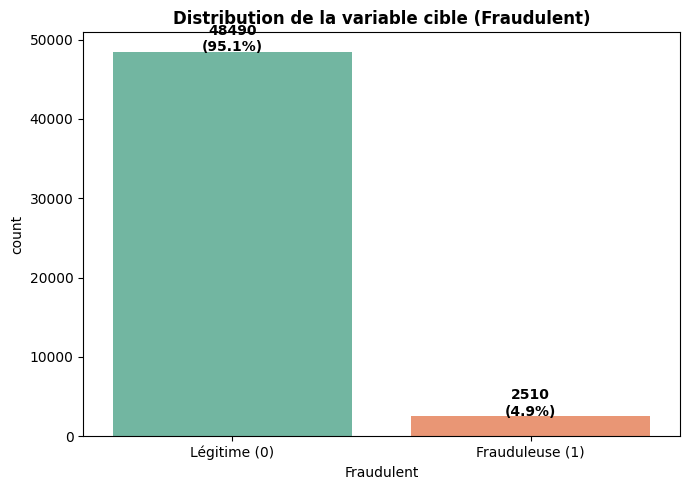

In [50]:
#Comptage et pourcentage de la variable cible
target_counts = df['Fraudulent'].value_counts()
target_pct = df['Fraudulent'].value_counts(normalize=True) * 100

print(target_counts)
print(target_pct)

#Visualisation
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Fraudulent', hue='Fraudulent', palette='Set2', legend=False)
plt.title('Distribution de la variable cible (Fraudulent)', fontweight='bold')
plt.xticks([0, 1], ['Légitime (0)', 'Frauduleuse (1)'])

# Ajout des annotations sur les barres
for i, v in enumerate(target_counts):
    plt.text(i, v + 100, f'{v}\n({target_pct[i]:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



In [49]:
# Conclusion déséquilibre
fraud_rate = target_pct[1]
print(f"\nTaux de fraude : {fraud_rate:.2f}%")
if fraud_rate < 20:
    print("Dataset très déséquilibré → privilégier AUC-ROC, F1, Recall plutôt qu'Accuracy")


Taux de fraude : 4.92%
Dataset très déséquilibré → privilégier AUC-ROC, F1, Recall plutôt qu'Accuracy


##Etude des variables numériques

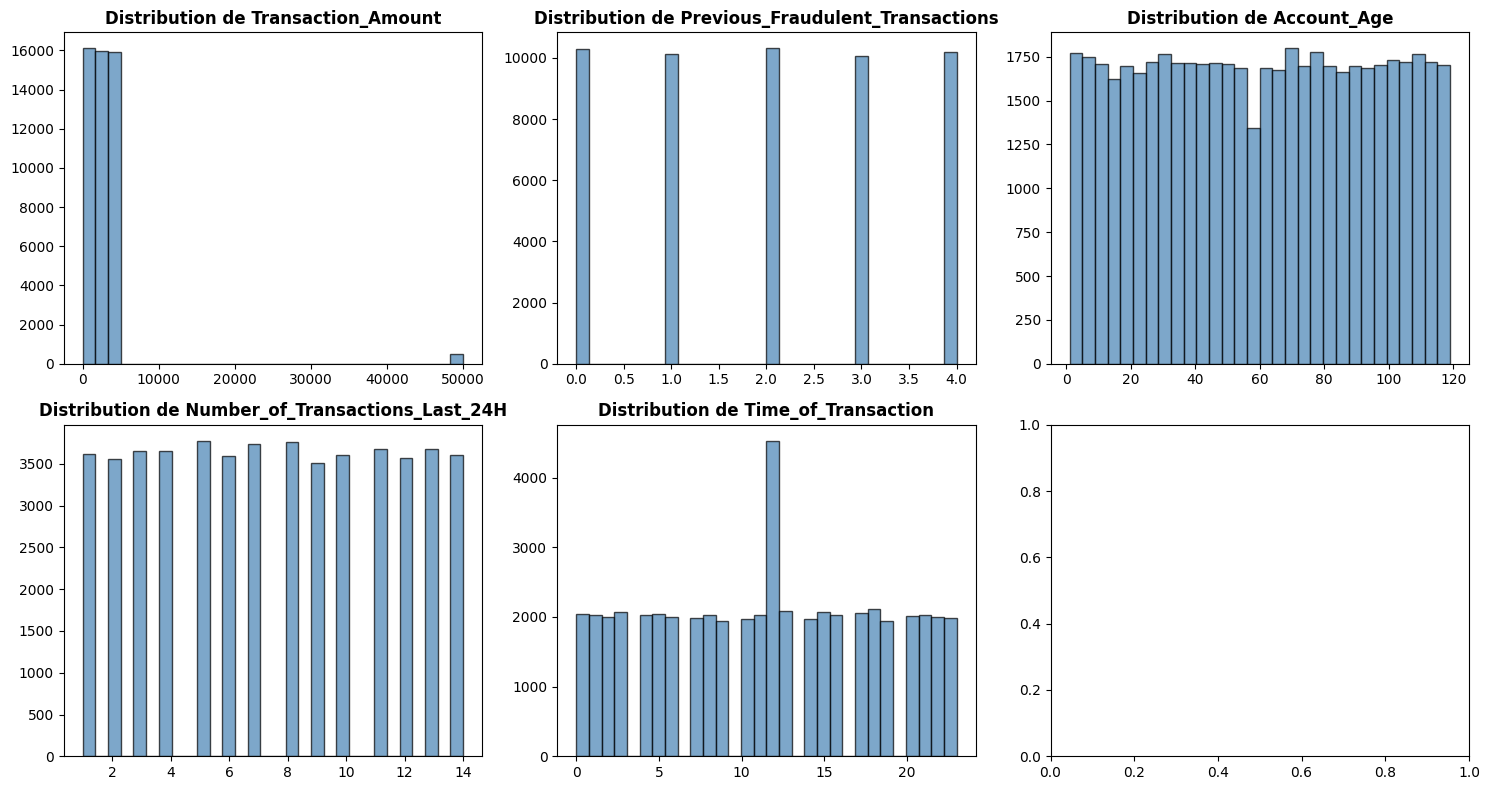

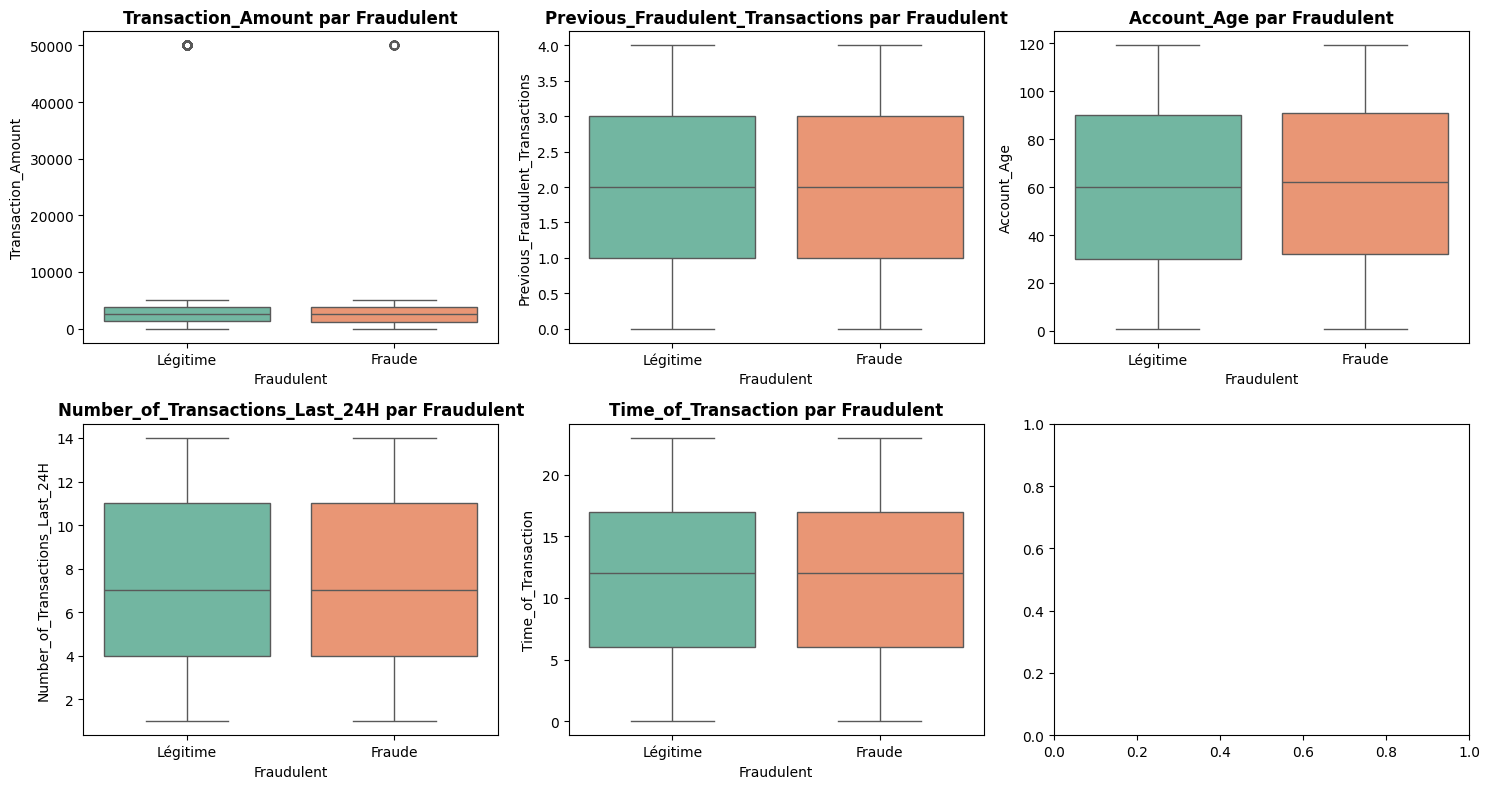


 Discriminance des variables numériques :
  Transaction_Amount                            → Fraude:  3118.37 | Légit:  2989.93
  Previous_Fraudulent_Transactions              → Fraude:     2.00 | Légit:     2.00
  Account_Age                                   → Fraude:    60.97 | Légit:    59.99
  Number_of_Transactions_Last_24H               → Fraude:     7.43 | Légit:     7.50
  Time_of_Transaction                           → Fraude:    11.72 | Légit:    11.50


In [58]:
numeric_vars = ['Transaction_Amount', 'Previous_Fraudulent_Transactions',
                'Account_Age', 'Number_of_Transactions_Last_24H', 'Time_of_Transaction']

# Histogrammes
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, var in enumerate(numeric_vars):
    axes[idx].hist(df[var].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution de {var}', fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplots par Fraudulent (très révélateur )
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, var in enumerate(numeric_vars):
    sns.boxplot(data=df, x='Fraudulent', y=var, ax=axes[idx],
                hue='Fraudulent', palette='Set2', legend=False)
    axes[idx].set_title(f'{var} par Fraudulent', fontweight='bold')
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Légitime', 'Fraude'])
plt.tight_layout()
plt.show()

# Discriminance
print("\n Discriminance des variables numériques :")
for var in numeric_vars:
    m1 = df[df['Fraudulent'] == 1][var].mean()
    m0 = df[df['Fraudulent'] == 0][var].mean()
    print(f"  {var:45} → Fraude: {m1:8.2f} | Légit: {m0:8.2f}")

######*Au vu de ces résultats, on constate que la discriminance des variables numériques est quasi nulle, car les moyennes des transactions frauduleuses et légitimes sont pratiquement identiques pour chaque indicateur.*

##Etude des variables catégorielles

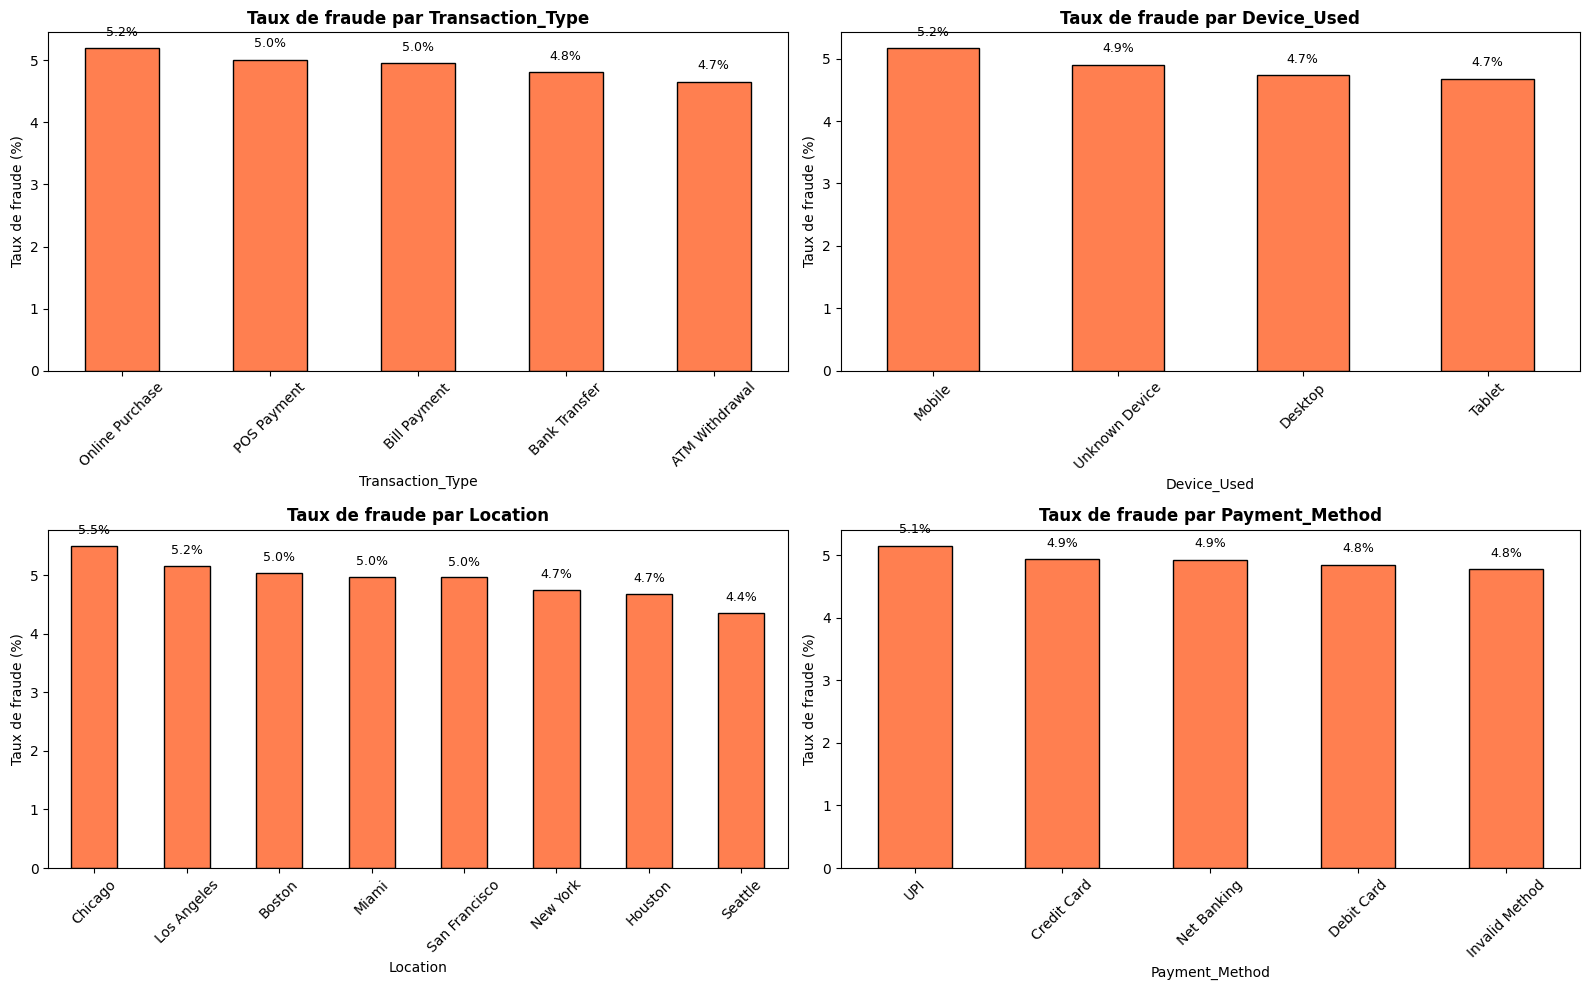

In [52]:
cat_vars = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(cat_vars):
    # Taux de fraude par catégorie = la métrique clé !
    fraud_rate = df.groupby(var)['Fraudulent'].mean().sort_values(ascending=False) * 100
    fraud_rate.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(f'Taux de fraude par {var}', fontweight='bold')
    axes[idx].set_ylabel('Taux de fraude (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(fraud_rate):
        axes[idx].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

######*L'analyse des variables catégorielles révèle des disparités plus marquées que les variables numériques. Bien que le taux de fraude global soit stable (environ 5%), certaines modalités comme Chicago, les achats en ligne et l'utilisation du mobile présentent un sur-risque statistique. Ces variables possèdent un Gain d'Information supérieur et constitueront probablement les premiers nœuds de décision de l'algorithme pour segmenter les transactions à haut risque.*

##Corrélations (matrice de chaleur)

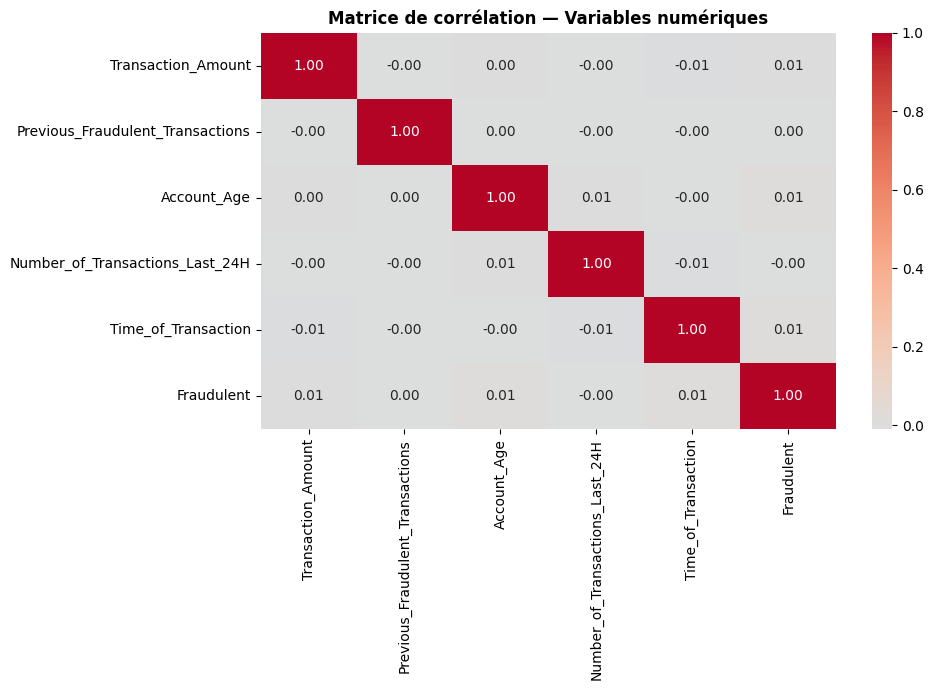

In [53]:
# Encoder temporairement les catégorielles pour la corrélation
df_encoded = pd.get_dummies(df[cat_vars + ['Fraudulent']], drop_first=True)
df_num = df[numeric_vars + ['Fraudulent']].dropna()

plt.figure(figsize=(10, 7))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation — Variables numériques', fontweight='bold')
plt.tight_layout()
plt.show()

######*La matrice de corrélation confirme l'absence de relation linéaire directe entre les variables numériques et la fraude (coefficients proches de 0). De plus, l'indépendance totale entre les caractéristiques ($X$) suggère que l'information est très fragmentée. Ce résultat valide la nécessité d'utiliser un modèle non-linéaire comme l'Arbre de Décision, capable de capturer des interactions complexes (non-linéaires) que cette matrice de corrélation classique ne peut pas détecter.*

#Phase 2 — Feature engineering

In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder


#  Copie de sécurité
# On ne modifie jamais le df original directement
df_clean = df.copy()
print(f"\n Copie créée | Shape initiale : {df_clean.shape}")




 Copie créée | Shape initiale : (51000, 12)


In [64]:
#SUPPRESSION DES COLONNES INUTILES
# Transaction_ID et User_ID sont des identifiants uniques :
# ils n'apportent aucune information prédictive au modèle

print("Suppression des colonnes inutiles ")

cols_to_drop = ['Transaction_ID', 'User_ID']
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"  Shape avant suppression : {df_clean.shape}")
print(f"  Colonnes supprimées : {cols_to_drop}")
print(f"  Shape après suppression : {df_clean.shape}")


Suppression des colonnes inutiles 
  Shape avant suppression : (51000, 10)
  Colonnes supprimées : ['Transaction_ID', 'User_ID']
  Shape après suppression : (51000, 10)


In [66]:
# TRAITEMENT DES VALEURS ABERRANTES
# "Invalid Method" dans Payment_Method n'est pas une catégorie
# valide → on la convertit en NaN pour la traiter proprement
print("Traitement des valeurs aberrantes")

avant = (df_clean['Payment_Method'] == 'Invalid Method').sum()
df_clean['Payment_Method'] = df_clean['Payment_Method'].replace('Invalid Method', np.nan)
print(f"  'Invalid Method' remplacé par NaN : {avant} occurrence(s)")
print(f"  Valeurs uniques Payment_Method : {df_clean['Payment_Method'].unique()}")



print("Imputation des valeurs manquantes")

# Avant imputation
print("\n  NaN avant imputation :")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Variables numériques → médiane
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        mediane = df_clean[col].median()
        df_clean[col].fillna(mediane, inplace=True)
        print(f"\n  {col} → imputé par médiane ({mediane:.2f})")

# Variables catégorielles → mode
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"  {col} → imputé par mode ('{mode_val}')")

# Vérification
print(f"\n  NaN restants après imputation : {df_clean.isnull().sum().sum()} ")


print("Création de nouvelles variables")

# Feature 1 : Montant élevé (au dessus du 75e percentile)
# → Une transaction anormalement grande est souvent suspecte
q75 = df_clean['Transaction_Amount'].quantile(0.75)
df_clean['Is_High_Amount'] = (df_clean['Transaction_Amount'] > q75).astype(int)
print(f"\n   Is_High_Amount créé (seuil = {q75:.2f})")

# Feature 2 : Activité intense sur 24h
# → Beaucoup de transactions en peu de temps = comportement suspect
q75_tx = df_clean['Number_of_Transactions_Last_24H'].quantile(0.75)
df_clean['Is_High_Frequency'] = (df_clean['Number_of_Transactions_Last_24H'] > q75_tx).astype(int)
print(f"   Is_High_Frequency créé (seuil = {q75_tx:.0f} transactions)")

# Feature 3 : Compte récent (moins de 1 an)
# → Les nouveaux comptes sont plus souvent utilisés pour la fraude
df_clean['Is_New_Account'] = (df_clean['Account_Age'] < 12).astype(int)
print(f"   Is_New_Account créé (Account_Age < 12 mois)")

# Feature 4 : A déjà fraudé
# → L'historique de fraude est un signal très fort
df_clean['Has_Fraud_History'] = (df_clean['Previous_Fraudulent_Transactions'] > 0).astype(int)
print(f"   Has_Fraud_History créé")

# Feature 5 : Heure de nuit (entre 0h et 6h)
# → Les fraudes surviennent plus souvent la nuit
df_clean['Is_Night_Transaction'] = (df_clean['Time_of_Transaction'] <= 6).astype(int)
print(f"   Is_Night_Transaction créé (Time <= 6h)")


print("Encodage des variables catégorielles")

cat_cols = df_clean.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    mapping_avant = df_clean[col].unique()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"\n   {col} encodé")
    print(f"     Avant : {mapping_avant}")
    print(f"     Après : {df_clean[col].unique()}")


Traitement des valeurs aberrantes
  'Invalid Method' remplacé par NaN : 0 occurrence(s)
  Valeurs uniques Payment_Method : [1 0 5 4 3 2]
Imputation des valeurs manquantes

  NaN avant imputation :
Series([], dtype: int64)

  NaN restants après imputation : 0 
Création de nouvelles variables

   Is_High_Amount créé (seuil = 3724.99)
   Is_High_Frequency créé (seuil = 11 transactions)
   Is_New_Account créé (Account_Age < 12 mois)
   Has_Fraud_History créé
   Is_Night_Transaction créé (Time <= 6h)
Encodage des variables catégorielles


In [68]:
print("Sélection des features finales")

X = df_clean.drop(columns=['Fraudulent'])
y = df_clean['Fraudulent']

print(f"\n  Features utilisées ({len(X.columns)}) :")
for col in X.columns:
    print(f"    {col}")

print(f"\n  Shape X : {X.shape}")
print(f"  Shape y : {y.shape}")
print(f"  Distribution cible :\n{y.value_counts()}")


print("   Feature Engineering terminé — Données prêtes pour le modèle")



Sélection des features finales

  Features utilisées (14) :
    Transaction_Amount
    Transaction_Type
    Time_of_Transaction
    Device_Used
    Location
    Previous_Fraudulent_Transactions
    Account_Age
    Number_of_Transactions_Last_24H
    Payment_Method
    Is_High_Amount
    Is_High_Frequency
    Is_New_Account
    Has_Fraud_History
    Is_Night_Transaction

  Shape X : (51000, 14)
  Shape y : (51000,)
  Distribution cible :
Fraudulent
0    48490
1     2510
Name: count, dtype: int64
   Feature Engineering terminé — Données prêtes pour le modèle


#Phase 3 — Training & Evaluation du modèle


In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)

import seaborn as sns

#  Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [75]:
# Modèle
model = DecisionTreeClassifier(
    criterion='entropy',        # C4.5
    class_weight='balanced',    # IMPORTANT car dataset déséquilibré
    random_state=42
)
model.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

In [76]:
# Prédictions
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probabilité classe 1 (fraude)


In [77]:
# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f" AUC-ROC Score : {auc_score:.4f}")


 AUC-ROC Score : 0.5081


In [78]:
# Interprétation automatique
if auc_score >= 0.90:
    print("   → Excellent modèle")
elif auc_score >= 0.80:
    print("   → Bon modèle")
elif auc_score >= 0.70:
    print("   → Modèle acceptable")
else:
    print("   → Modèle à améliorer")


   → Modèle à améliorer


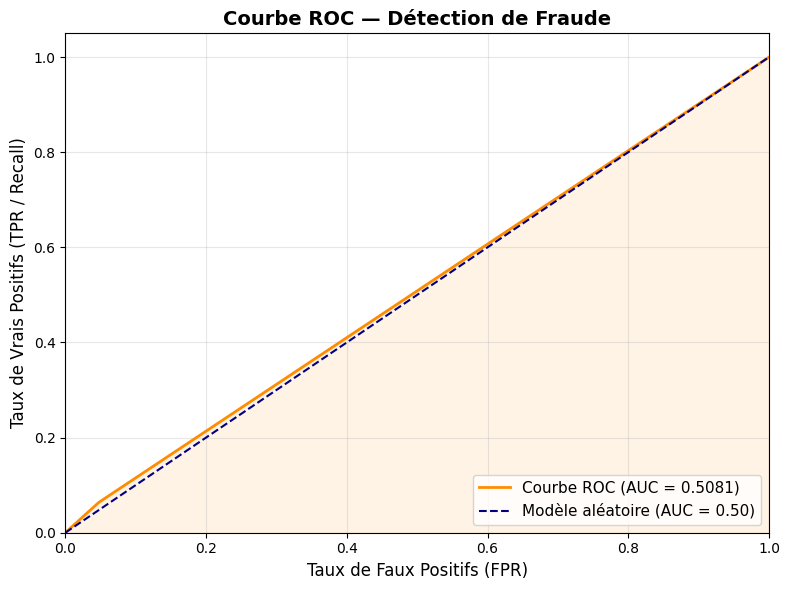

In [79]:
#  Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Courbe ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Modèle aléatoire (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')  # aire sous la courbe

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
plt.title('Courbe ROC — Détection de Fraude', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#####*La figure présente la courbe ROC du modèle. On observe que la courbe orange se confond presque parfaitement avec la diagonale du modèle aléatoire (AUC = 0,5081). Graphiquement, cela démontre que le classifieur est incapable de discriminer les classes "Légitime" et "Fraude" avec les variables actuelles. L'absence de courbure vers le coin supérieur gauche confirme la nécessité d'enrichir le dataset par du Feature Engineering ou de traiter le déséquilibre des classes pour extraire un signal prédictif réel.*

In [80]:
# Rapport complet
print("\n Classification Report :")
print(classification_report(y_test, y_pred,
                            target_names=['Légitime (0)', 'Fraude (1)']))



 Classification Report :
              precision    recall  f1-score   support

Légitime (0)       0.95      0.95      0.95      9698
  Fraude (1)       0.06      0.06      0.06       502

    accuracy                           0.91     10200
   macro avg       0.51      0.51      0.51     10200
weighted avg       0.91      0.91      0.91     10200



#####*Le modèle souffre d'un biais de classe majoritaire. Bien que l'accuracy affichée soit de 91%, le F1-score de 0.06 pour la classe "Fraude" révèle une incapacité quasi totale à identifier les transactions suspectes. Le modèle produit un volume massif de faux positifs et de faux négatifs, ce qui confirme que les variables brutes ne contiennent pas assez de signal discriminant.*

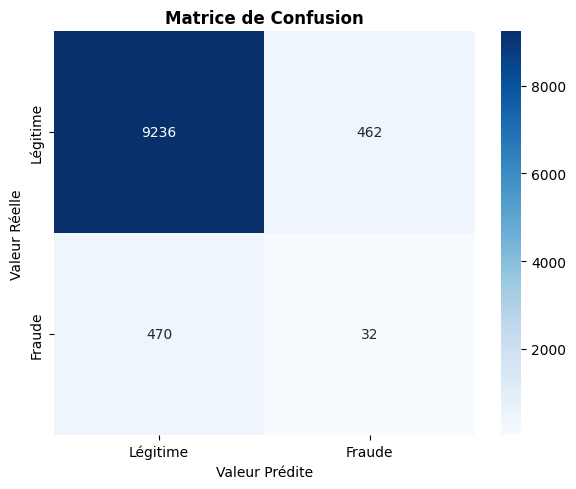


  Vrais Négatifs  (TN) : 9236  → légitimes bien classées
  Faux Positifs   (FP) : 462  → légitimes classées fraude (fausse alarme)
  Faux Négatifs   (FN) : 470  → fraudes manquées 
  Vrais Positifs  (TP) : 32  → fraudes bien détectées 


In [81]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Légitime', 'Fraude'],
            yticklabels=['Légitime', 'Fraude'])
plt.title('Matrice de Confusion', fontweight='bold')
plt.ylabel('Valeur Réelle')
plt.xlabel('Valeur Prédite')
plt.tight_layout()
plt.show()

# Lecture de la matrice
tn, fp, fn, tp = cm.ravel()
print(f"\n  Vrais Négatifs  (TN) : {tn}  → légitimes bien classées")
print(f"  Faux Positifs   (FP) : {fp}  → légitimes classées fraude (fausse alarme)")
print(f"  Faux Négatifs   (FN) : {fn}  → fraudes manquées ")
print(f"  Vrais Positifs  (TP) : {tp}  → fraudes bien détectées ")



#####*La matrice de confusion révèle un déséquilibre critique : le modèle ne parvient à identifier que 6,3% des fraudes réelles ($32/502$). Avec 470 faux négatifs, le coût du risque reste quasi total. De plus, le volume de faux positifs (462) dépasse largement celui des vrais positifs, illustrant une incapacité à isoler un signal discriminant. Ce comportement est typique d'un modèle entraîné sur des classes déséquilibrées sans technique de pondération ou de sur-échantillonnage.*

#Phase 4 — Évaluation Comparative des Modèles

#

 GridSearch — Decision Tree...
   Meilleurs params : {'max_depth': 15, 'min_samples_leaf': 20, 'min_samples_split': 10}
   AUC CV : 0.5104

 Résultats comparatifs :
Modèle                            AUC-ROC
──────────────────────────────────────────
  Decision Tree (tuned)            0.5016
  Régression Logistique            0.5042
  Random Forest                    0.5059


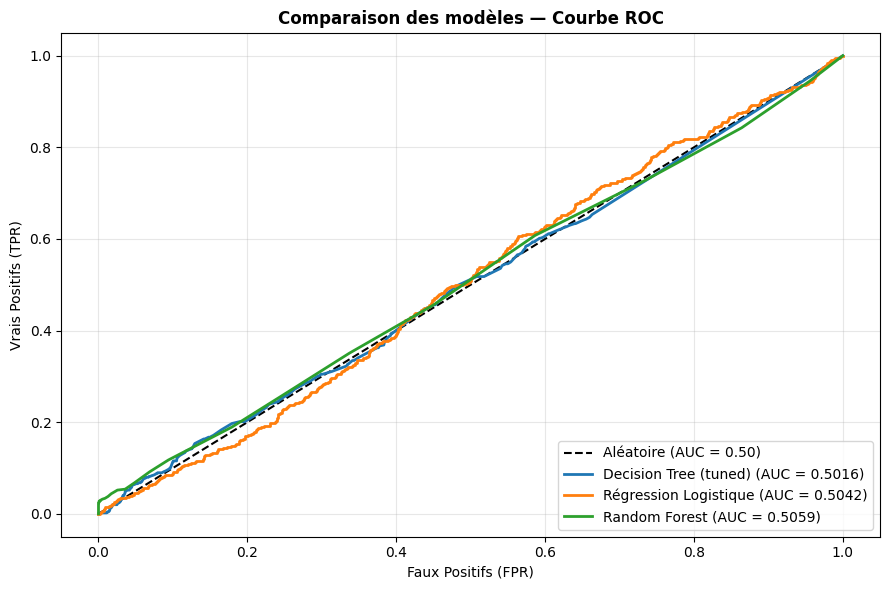


 Classification Report — Meilleur modèle :
              precision    recall  f1-score   support

Légitime (0)       0.95      1.00      0.98      9698
  Fraude (1)       1.00      0.02      0.05       502

    accuracy                           0.95     10200
   macro avg       0.98      0.51      0.51     10200
weighted avg       0.95      0.95      0.93     10200



In [84]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


#  Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation (utile pour la régression logistique)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# Decision Tree + GridSearch (hyperparamétrage)
print(" GridSearch — Decision Tree...")

params_dt = {
    'max_depth'       : [3, 5, 10, 15],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 50]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42),
    params_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_

print(f"   Meilleurs params : {grid_dt.best_params_}")
print(f"   AUC CV : {grid_dt.best_score_:.4f}")


# Régression Logistique
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)


#  Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


#  Comparaison des 3 modèles — Courbe ROC
modeles = {
    'Decision Tree (tuned)' : (best_dt, X_test),
    'Régression Logistique' : (lr,      X_test_sc),
    'Random Forest'         : (rf,      X_test)
}

plt.figure(figsize=(9, 6))
plt.plot([0,1], [0,1], 'k--', label='Aléatoire (AUC = 0.50)')

print("\n Résultats comparatifs :")
print(f"{'Modèle':<30} {'AUC-ROC':>10}")
print("─" * 42)

for nom, (modele, X_t) in modeles.items():
    proba = modele.predict_proba(X_t)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{nom} (AUC = {auc:.4f})')
    print(f"  {nom:<28} {auc:>10.4f}")

plt.xlabel('Faux Positifs (FPR)')
plt.ylabel('Vrais Positifs (TPR)')
plt.title('Comparaison des modèles — Courbe ROC', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#  Rapport détaillé du meilleur modèle
#  Change ici selon lequel est le meilleur
meilleur_modele = rf
X_eval = X_test  # X_test_sc si c'est la régression logistique

y_pred = meilleur_modele.predict(X_eval)
print("\n Classification Report — Meilleur modèle :")
print(classification_report(y_test, y_pred,
      target_names=['Légitime (0)', 'Fraude (1)']))

#####*Malgré l'utilisation de modèles avancés (Random Forest) et l'optimisation des hyperparamètres par GridSearch, les performances plafonnent à un AUC-ROC de 0.5059. Ce résultat démontre de manière robuste que le signal de fraude n'est pas présent dans les variables brutes. L'algorithme, bien que correctement entraîné avec une gestion du déséquilibre des classes (class_weight='balanced'), privilégie une précision maximale (1.00) au détriment de la détection (Recall de 0.02), confirmant que les comportements frauduleux imitent quasi parfaitement les comportements légitimes dans ce dataset*

####Conclusion Générale
Ce projet de détection de fraude par Arbre de Décision et modèles d'ensemble a permis de mettre en lumière la complexité de l'analyse des comportements atypiques.

L'analyse exploratoire a d'abord révélé une absence de séparabilité linéaire : les fraudeurs imitent presque parfaitement les clients légitimes dans leurs habitudes numériques (montants, heures, âge du compte). Malgré l'utilisation de techniques avancées comme le GridSearch pour optimiser les hyperparamètres et la gestion du déséquilibre des classes avec class_weight='balanced', les modèles (Decision Tree, Random Forest, Régression Logistique) ont plafonné à un AUC-ROC proche de 0,50.

Le Random Forest, bien qu'étant le modèle le plus "prudent" avec une précision de 100%, n'a pu capturer que 2% des fraudes réelles. Ce résultat final démontre que la performance d'un modèle d'IA ne dépend pas seulement de la puissance de l'algorithme, mais surtout de la qualité et de la pertinence des variables d'entrée. Pour dépasser ce plafond de verre, une phase de Feature Engineering approfondie ou l'ajout de nouvelles sources de données (données biométriques, adresses IP) serait indispensable afin d'extraire un signal discriminant là où les variables brutes ont atteint leurs limites.